# 07 — Exploratory analysis: the questions behind the Democratic Funnel

**The Democratic Funnel** · Team UL · DIRISA Student Datathon Challenge 2026

**Purpose.** How many South Africans register to vote, how many registered voters actually vote, where turnout
is lowest, what goes together with low turnout, and how participation differs by age.

**Reads:** `data/processed/master.csv` (made by `06_master`)  **Writes:** charts to `reports/figures/q0N_*.png`

Every municipality loses people at two points on the way to the ballot box:

```
Adults who may vote  →  People who registered  →  People who voted
        E                        R                       V
            registration leak         turnout leak
```

**Registration rate** `r = R / E` · **Turnout** `t = V / R` · **Real participation** `p = r × t = V / E`

| # | Question | Chart |
|---|---|---|
| | **A. Turnout and registration** | |
| Q1 | How have registration and turnout changed, 2011–2026? | `q01_registration_turnout` |
| Q2 | How does turnout differ between provinces? | `q02_provinces` |
| Q3 | Which municipalities have the lowest turnout over the years? | `q03_lowest_turnout` |
| | **B. Who** | |
| Q4 | Which age group has the lowest participation? | `q04_age_groups` |
| | **C. What goes with low turnout** | |
| Q5 | Which municipal characteristics are linked to low turnout? | `q05_correlations` |
| Q6 | Does low turnout cluster geographically? | `q06_clustering` |
| Q7 | How does population density affect low turnout? | `q07_density` |
| | **D. What to do** | |
| Q8 | Where should effort go before 4 November 2026? | table |

Each question ends with an **Answer** and, where needed, **Careful** (what the data does *not* show).
Run the setup cells first.

## 0. Setup

In [28]:
import sys, subprocess
from pathlib import Path

REPO_URL = "https://github.com/Thato20-M/democratic-funnel.git"
IN_COLAB = "google.colab" in sys.modules

if IN_COLAB:
    from google.colab import drive
    drive.mount("/content/drive")
    REPO_DIR = Path("/content/democratic-funnel")
    url = REPO_URL
    try:
        from google.colab import userdata
        url = REPO_URL.replace("https://", f"https://{userdata.get('GITHUB_TOKEN')}@")
    except Exception:
        print("No GITHUB_TOKEN in Colab Secrets - cloning will fail for the private repo")
    if REPO_DIR.exists():
        subprocess.run(["git", "-C", str(REPO_DIR), "pull", "-q"], check=True)
    else:
        subprocess.run(["git", "clone", "-q", url, str(REPO_DIR)], check=True)
else:
    REPO_DIR = next(p for p in [Path.cwd(), *Path.cwd().parents]
                    if (p / "src" / "config.py").exists())

if str(REPO_DIR) not in sys.path:
    sys.path.insert(0, str(REPO_DIR))
print("Repo:", REPO_DIR)

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Repo: /content/democratic-funnel


In [ ]:
from src import config
from src.config import INTERIM, PROCESSED, FIGURES

import numpy as np, pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import warnings; warnings.filterwarnings("ignore", category=FutureWarning)

config.make_dirs(); config.set_seed()
pd.set_option("display.max_columns", 60); pd.set_option("display.width", 170)
print(config.describe())

Environment: Colab
Repo root:   /content/democratic-funnel
Work root:   /content/drive/MyDrive/DIRISA_SDC


### House style: one set of colours and words, used everywhere

The same colours mean the same thing in this notebook, on the slides and in the dashboard.

| Colour | Means |
|---|---|
| **Blue** | registration (the roll) |
| **Amber** | turnout (voting) |
| **Crimson** | both problems / the key finding |
| **Green** | healthy |
| **Navy** | national figures |

Amber and light green are pale on white, so **every chart that uses them also has written labels** — colour never
carries meaning on its own. `LABELS` turns column names into plain English.

In [ ]:
BLUE, AMBER, CRIMSON, GREEN, NAVY = "#2a78d6", "#eda100", "#a3143a", "#7bc586", "#1b2f5b"
LIGHT_BLUE, LIGHT_AMBER = "#9ec5f0", "#f6d58a"         # tints for context (no grey: team rule)
YEAR_COLOURS = {2011: LIGHT_BLUE, 2016: LIGHT_AMBER, 2021: AMBER}
INK, INK2, GRID, SURFACE = "#0b0b0b", "#4a4a47", "#e4e3de", "#ffffff"

GROUPS = ["Low registration", "Low turnout", "Both low", "Healthy"]
WHAT_TO_SEND = {"Low registration": "registration drive, ID and address help",
                "Low turnout": "voter education and mobilisation",
                "Both low": "both - first priority",
                "Healthy": "nothing urgent"}

LABELS = {
    "r": "Registration rate", "t": "Turnout", "p": "Real participation",
    "leak_reg": "Registration vs typical municipality", "leak_turn": "Turnout vs typical municipality",
    "registered": "Registered voters", "votes_cast": "Votes cast", "eligible_adults": "Adults who may vote",
    "higher_ed_rate": "Adults with higher education", "piped_water_rate": "Households with piped water",
    "electricity_rate": "Households with electricity", "refuse_removal_rate": "Households with refuse removal",
    "log_density": "Population density", "spatial_lag_turnout": "Neighbours' turnout",
    "muni_name": "Municipality", "province": "Province",
}

plt.rcParams.update({                                    # large text: these charts go on slides
    "figure.dpi": 110, "savefig.dpi": 200, "figure.facecolor": SURFACE, "axes.facecolor": SURFACE,
    "savefig.facecolor": SURFACE, "axes.edgecolor": GRID, "axes.linewidth": 0.8,
    "axes.labelcolor": INK2, "axes.titlecolor": INK, "axes.titlesize": 14, "axes.titleweight": "bold",
    "axes.titlepad": 12, "axes.labelsize": 12, "xtick.color": INK2, "ytick.color": INK2,
    "xtick.labelsize": 12, "ytick.labelsize": 12, "grid.color": GRID, "grid.linewidth": 0.7,
    "legend.frameon": False, "legend.fontsize": 12, "font.size": 12,          # 12pt minimum (team rule)
})


def tidy(ax, xgrid=False, ygrid=True):
    """Recessive axes: no box, gridlines behind the data only where they help reading."""
    for s in ("top", "right"):
        ax.spines[s].set_visible(False)
    for s in ("left", "bottom"):
        ax.spines[s].set_color(GRID)
    ax.set_axisbelow(True)
    ax.grid(ygrid, axis="y"); ax.grid(xgrid, axis="x")
    return ax


def pct(ax, axis="y"):
    (ax.yaxis if axis == "y" else ax.xaxis).set_major_formatter(mtick.PercentFormatter(1.0, decimals=0))
    return ax


def save(fig, name):
    fig.savefig(FIGURES / f"{name}.png", bbox_inches="tight")
    print("saved", name)


def group_of(reg_gap, turn_gap):
    """Below the typical (median) municipality on registration and/or turnout."""
    return pd.Series(np.select([(reg_gap < 0) & (turn_gap < 0), reg_gap < 0, turn_gap < 0],
                               ["Both low", "Low registration", "Low turnout"], "Healthy"),
                     index=reg_gap.index)

## 1. Load and check the data

`master.csv` has one row per municipality per election: 213 municipalities × 4 elections (2011, 2016, 2021, 2026)
= 852 rows. 2011 results are already moved onto today's boundaries (`06_master`). 2026 has registration but no votes
yet — that election has not happened.

In [ ]:
master = pd.read_csv(PROCESSED / "master.csv")
assert master.groupby("election")["muni_code"].nunique().to_dict() == {2011: 213, 2016: 213, 2021: 213, 2026: 213}
assert not master.duplicated(["election", "muni_code"]).any()

# today's municipality names everywhere (some IEC files use older names or CAPITALS)
current_name = master[master["election"] == 2026].set_index("muni_code")["muni_name"]
current_name = current_name.where(~current_name.str.isupper(), current_name.str.title())
master["muni_name"] = master["muni_code"].map(current_name)

held = master[master["election"] < 2026].copy()          # elections that actually happened
y21 = master[master["election"] == 2021].copy()
y26 = master[master["election"] == 2026].copy()

missing = master.isna().groupby(master["election"]).sum().T
print("Missing values per column (only columns with any):")
print(missing[missing.sum(axis=1) > 0].to_string())

Missing values per column (only columns with any):
election                 2011  2016  2021  2026
muni_type                   0     0     0   213
valid_votes                 0     0     0   213
spoilt                      0     0     0   213
votes_cast                  0     0     0   213
turnout                     0     0     0   213
boundary_2016               0     0     0   213
comparable_2011             0     0     0   213
covid_shock                 0     0     0   213
registered_youth          213   213   213     0
byelection_turnout_mean   213   213   213   213
byelection_count          213   213   213   213
t                           0     0     0   213
p                           0     0     0   213
leak_turn                   0     0     0   213
t_prev                    213     0     0     0
r_prev                    213     0     0     0
dt                        213     0     0   213
spatial_lag_turnout         0     0     0   213


**Every missing value has a reason.** 2026 has no votes or turnout (not held yet). 2011 has no "previous election"
columns. `registered_youth` exists for 2026 only — the IEC publishes registration by age for the current roll, not
for past elections. The by-election columns are empty: by-elections were dropped (they did not happen everywhere).

## Metric definitions

| Metric | Formula | Denominator |
|---|---|---|
| **Turnout** | Votes cast ÷ Registered voters | People on the voters' roll |
| **Registration rate** | Registered voters ÷ Adults who may vote | Census 2022 citizens aged 18+ |
| **Real participation** | Votes cast ÷ Adults who may vote | Census 2022 citizens aged 18+ |

"Turnout" on its own always means the first. National rates come from **summed counts** (total votes ÷ total
registered), not an average of municipal percentages, so a large metro counts in proportion to its size.
All rates are fractions (0.45 = 45%).

---
# A. Turnout and registration

## Q1. How have registration and turnout changed, 2011–2026?

In [ ]:
nat = master.groupby("election")[["registered", "votes_cast", "eligible_adults"]].sum(min_count=1)
nat["r"] = nat["registered"] / nat["eligible_adults"]
nat["t"] = nat["votes_cast"] / nat["registered"]
print((nat.assign(registered=lambda d: (d.registered / 1e6).round(2), votes_cast=lambda d: (d.votes_cast / 1e6).round(2),
                  r=lambda d: (d.r * 100).round(1), t=lambda d: (d.t * 100).round(1))
       [["registered", "votes_cast", "r", "t"]]
       .rename(columns={"registered": "registered (m)", "votes_cast": "votes cast (m)",
                        "r": "registration %", "t": "turnout %"}).to_string()))

turnout_held = nat.loc[nat.index < 2026, "t"]
fig, ax = plt.subplots(figsize=(9, 5.2))
ax.plot(nat.index, nat["r"], marker="o", lw=2.5, ms=8, color=BLUE, label="Registration rate (% of adults who may vote)")
ax.plot(turnout_held.index, turnout_held, marker="s", lw=2.5, ms=8, color=AMBER, label="Turnout (% of registered voters)")
for yr, v in nat["r"].items():
    ax.annotate(f"{v:.1%}", (yr, v), textcoords="offset points", xytext=(0, 10), ha="center", weight="bold", color=BLUE)
for yr, v in turnout_held.items():
    ax.annotate(f"{v:.1%}", (yr, v), textcoords="offset points", xytext=(0, -18), ha="center", weight="bold",
                color=CRIMSON if yr == 2021 else AMBER)
ax.annotate("4 Nov 2026:\nnot held yet", (2026, 0.30), ha="center", va="center", fontsize=12, color=AMBER, weight="bold",
            bbox=dict(boxstyle="round,pad=0.4", facecolor=SURFACE, edgecolor=AMBER, linestyle="--"))
ax.set_ylim(0, 1); ax.set_xticks(nat.index); pct(ax); tidy(ax)
ax.set(xlabel="Local government election year", ylabel="Percentage", title="Registration vs Turnout (2011-2026)")
ax.legend(loc="upper center", bbox_to_anchor=(0.5, -0.15), ncol=2)
fig.text(0.01, -0.06, "All registration rates use the 2022 Census, so earlier years are understated.",
         fontsize=12, color=INK2, style="italic")
save(fig, "q01_registration_turnout"); plt.show()

**Answer.** More adults are on the roll than ever — the registration rate rose from about **59%** (2011) to **73%**
(2026) — but turnout **fell from about 58% to 46% in 2021**, the COVID election. The problem is less getting people
registered and more getting registered voters to the polls: the turnout leak widened.

**Careful.** Every year's registration rate divides by the **Census 2022** adult population, because there is no
census for 2016 or 2021. There were fewer adults in 2011, so the 2011 rate is understated and the rise is smaller
than the chart shows. Turnout has no such problem (both counts come from the IEC).

## Q2. How does turnout differ between provinces?

In [ ]:
prov = held.groupby(["province", "election"])[["registered", "votes_cast"]].sum()
prov = (prov["votes_cast"] / prov["registered"]).unstack("election").sort_values(2021, ascending=False)

fig, ax = plt.subplots(figsize=(10.5, 9))
y, h = np.arange(len(prov)), 0.25
for yr, dy in [(2011, h), (2016, 0), (2021, -h)]:
    bars = ax.barh(y + dy, prov[yr], h, label=str(yr), color=YEAR_COLOURS[yr])
    ax.bar_label(bars, labels=[f"{v:.1%}" for v in prov[yr]], padding=4, fontsize=12, color=INK2)
ax.set_yticks(y, prov.index); ax.set_xlim(0, 0.8); pct(ax, "x"); tidy(ax, xgrid=True, ygrid=False)
ax.set(xlabel="Turnout rate", ylabel="Province", title="Turnout by province")
ax.legend(title="Election", loc="upper left", bbox_to_anchor=(1.02, 1))
save(fig, "q02_provinces"); plt.show()

print((prov.assign(change_2016_2021=prov[2021] - prov[2016]) * 100).round(1).to_string())

**Answer.** Turnout fell in **every province** in 2021, by about **6 to 15 points**. The **Northern Cape** had the
highest turnout in 2021 (53%). The lowest were **North West** (42.0%), **Mpumalanga** (42.5%) and **Gauteng** (43.4%).
**Limpopo** had the lowest turnout in 2011 and 2016 but the **smallest fall** in 2021 (about 6 points), while the
**Western Cape**, Gauteng, Mpumalanga and KwaZulu-Natal fell the most (13–15 points).

## Q3. Which municipalities have the lowest turnout over the years?

In [ ]:
tw = held.pivot_table(index="muni_code", columns="election", values="t")
tw["Average"] = tw[[2011, 2016, 2021]].mean(axis=1)
tw = tw.join(y26.set_index("muni_code")[["muni_name", "province"]])

# 2011 results were moved onto today's boundaries by area share (06_master). Where a municipality was created or
# re-drawn in 2016 (e.g. Collins Chabane), its 2011 turnout is an estimate: flag it.
try:
    cw = pd.read_csv(INTERIM / "muni_crosswalk_2011.csv")
    whole = cw.groupby("muni_code_2011")["share"].transform("sum")
    cw["part"] = cw["share"] / whole                          # share of the old municipality going to this one
    n_old = cw.groupby("muni_code_current")["muni_code_2011"].nunique()
    partial = cw.loc[cw["part"] < 0.99, "muni_code_current"].unique()
    estimated_2011 = set(n_old[n_old > 1].index) | set(partial)
except FileNotFoundError:
    estimated_2011 = set()
    print("muni_crosswalk_2011.csv not found (05_geography) - 2011 estimates are not flagged")

low10 = tw.nsmallest(10, "Average").iloc[::-1]
fig, ax = plt.subplots(figsize=(11, 9.5))
for yr, dy in [(2011, -0.27), (2016, 0), (2021, 0.27)]:
    bars = ax.barh(np.arange(10) + dy, low10[yr], height=0.26, color=YEAR_COLOURS[yr], label=str(yr))
    ax.bar_label(bars, labels=[f"{v:.1%}" for v in low10[yr]], padding=3, fontsize=12)
ax.set_yticks(range(10), [f"{m} ({p})" + ("*" if c in estimated_2011 else "")
                          for c, m, p in zip(low10.index, low10["muni_name"], low10["province"])])
ax.set_xlim(0, 0.62); pct(ax, "x"); tidy(ax, xgrid=True, ygrid=False)
ax.set(title="The 10 municipalities with the lowest average turnout (2011–2021)", xlabel="Turnout rate",
       ylabel="Municipality")
ax.legend(loc="upper center", bbox_to_anchor=(0.5, -0.1), ncols=3)
note = "Ranked by average turnout over the 2011, 2016 and 2021 elections."
if estimated_2011 & set(low10.index):
    note += "\n* 2011 turnout is estimated: the municipality was created or re-drawn in 2016."
fig.text(0.01, -0.08, note, fontsize=12, color=INK2, style="italic", va="top")
save(fig, "q03_lowest_turnout"); plt.show()

bottom20 = [set(tw[yr].nsmallest(20).index) for yr in (2011, 2016, 2021)]
print("In the bottom 20 in every election:", ", ".join(tw.loc[list(set.intersection(*bottom20)), "muni_name"]))
falls = (tw[2021] - tw[2016]).nsmallest(6)
print("Biggest falls 2016 -> 2021:", ", ".join(f"{tw.loc[c, 'muni_name']} ({v * 100:+.1f})" for c, v in falls.items()))
rose = low10[low10[2021] > low10[2016]]
print("Of the lowest 10, turnout rose in 2021 in:", ", ".join(rose["muni_name"]) or "none")
print("Lowest 10 in 2021 alone:", ", ".join(tw.nsmallest(10, 2021)["muni_name"]))

**Answer.** **Rustenburg (North West)** has the lowest turnout over the years: lowest in 2011 (45.0%) and 2021
(36.0%), and the lowest average across the three elections (43.7%). The chart ranks municipalities by that **average over
2011, 2016 and 2021**; seven of the ten lowest are in **Limpopo**.
Six municipalities were in the bottom 20 in **every** election: Rustenburg, King Sabata Dalindyebo, Thulamela,
Fetakgomo Tubatse, Mogalakwena and Thabazimbi.

The biggest **falls** in 2021 were elsewhere — in KwaZulu-Natal and the metros: Mkhambathini (−23.6 points),
Msunduzi, Mbombela, eThekwini, Nelson Mandela Bay and Cape Town (−17 to −19).

**Collins Chabane (Limpopo)** is different: it was created in 2016 (from parts of Thulamela and Makhado), so its
2011 turnout is an estimate, and its turnout **rose** in 2021 (45.2% → 47.4%). It is in the lowest ten because of
its low 2016 turnout, not because of 2021. Ranked on 2021 alone, the lowest ten are led by Rustenburg, Mafikeng
and Emalahleni.

**Careful.** Low turnout is a share of *registered* voters. A municipality with low turnout may still have a full
roll — and the other way round

---
# B. Who

## Q4. Which age group has the lowest participation?

Registration only: the IEC publishes registration by age, not turnout by age.

In [ ]:
youth_reg, youth_elig = y26["registered_youth"].sum(), y26["eligible_youth"].sum()
ages = pd.DataFrame({"registered": [youth_reg, y26["registered"].sum() - youth_reg],
                     "eligible": [youth_elig, y26["eligible_adults"].sum() - youth_elig]},
                    index=["18–29", "30+"])
ages["rate"] = ages["registered"] / ages["eligible"]

fig, ax = plt.subplots(figsize=(8.5, 3.4))
bars = ax.barh(ages.index, ages["rate"], height=0.55,
               color=[BLUE if a == "18–29" else NAVY for a in ages.index])
for rect, (a, row) in zip(bars, ages.iterrows()):
    ax.text(row["rate"] + 0.01, rect.get_y() + rect.get_height() / 2,
            f"{row['rate']:.1%}  ({row['registered'] / 1e6:.1f}m of {row['eligible'] / 1e6:.1f}m)", va="center")
ax.invert_yaxis(); ax.set_xlim(0, 1.1); pct(ax, "x"); tidy(ax, xgrid=True, ygrid=False)
ax.set(xlabel="Registration rate, 2026", ylabel=None, title="Young adults are far less likely to be registered (2026)")
ax.set(ylabel="Age")
save(fig, "q04_age_groups"); plt.show()

youth_rate = y26["registered_youth"] / y26["eligible_youth"]
older_rate = (y26["registered"] - y26["registered_youth"]) / (y26["eligible_adults"] - y26["eligible_youth"])
print(f"Youth rate below the 30+ rate in {(youth_rate < older_rate).sum()} of {len(y26)} municipalities")

**Answer.** **Young adults (18–29)** have by far the lowest participation: **46%** are registered (5.6 million of
12.0 million), against **85%** of adults aged 30 and older — and lower in 212 of the 213 municipalities.

**Careful.** This is registration only. Turnout by age is not published, so we cannot say whether registered young
people vote less.

---
# C. What goes with low turnout

## Q5. Which municipal characteristics are linked to low turnout?

**A link is not proof of a cause.** A pattern across municipalities cannot show why individuals do or do not vote
(the ecological fallacy). The honest version of "what causes low turnout" is "what is **associated** with it".

In [ ]:
y21["log_density"] = np.log(y21["pop_density"])
chars = ["higher_ed_rate", "piped_water_rate", "electricity_rate", "refuse_removal_rate", "log_density",
         "spatial_lag_turnout"]
corr = y21[["leak_reg", "leak_turn"] + chars].corr().loc[chars, ["leak_reg", "leak_turn"]]

fig, ax = plt.subplots(figsize=(7.5, 6))
im = ax.imshow(corr, cmap="RdBu_r", vmin=-1, vmax=1, aspect="auto")
ax.set_xticks([0, 1], ["Registration vs\ntypical", "Turnout vs\ntypical"])
ax.set_yticks(range(len(chars)), [LABELS[c] for c in chars])
ax.xaxis.tick_top()
for i in range(len(chars)):
    for j in range(2):
        v = corr.iloc[i, j]
        ax.text(j, i, f"{v:.2f}", ha="center", va="center", fontsize=13, weight="bold",
                color="white" if abs(v) > .55 else INK)
ax.set_title("What goes with low registration and low turnout, 2021", pad=58)
for s in ax.spines.values():
    s.set_visible(False)
fig.colorbar(im, ax=ax, shrink=0.8, label="correlation")
save(fig, "q05_correlations"); plt.show()

print(f"Registration gap vs turnout gap: {y21['leak_reg'].corr(y21['leak_turn']):.2f}")
print(f"Water vs refuse removal: {y21['piped_water_rate'].corr(y21['refuse_removal_rate']):.2f}")
print(corr.rename(index=LABELS, columns=LABELS).round(2).to_string())

**Answer.**
- **Registration and turnout are only loosely related** (correlation **0.30**): the two leaks are largely different
  problems, so the published turnout figure alone is not enough to plan a response.
- **Density matters most:** denser municipalities had lower turnout in 2021 (**−0.50**). The densest places also fell
  the most in 2021.
- **Services and education:** their simple links with turnout in 2021 are weak (0.02 to 0.12). Water and refuse
  removal move together (0.78), so they are one "services" signal, not separate ones.
- **Neighbours matter:** turnout is strongly related to neighbours' turnout (**0.64**, see Q6).

**Careful.** These are simple correlations. `08_model` (section 3b) tests each Census factor properly — on the change
in turnout, with density and province held constant, bootstrapped and cross-validated. **None of the services or
education factors holds up**, so they are not in the model. Better-serviced municipalities fell more in 2021 only,
not before (2011 → 2016). It points to COVID hitting urban-type places, not to services driving turnout.

## Q6. Does low turnout cluster geographically?

saved q06_clustering


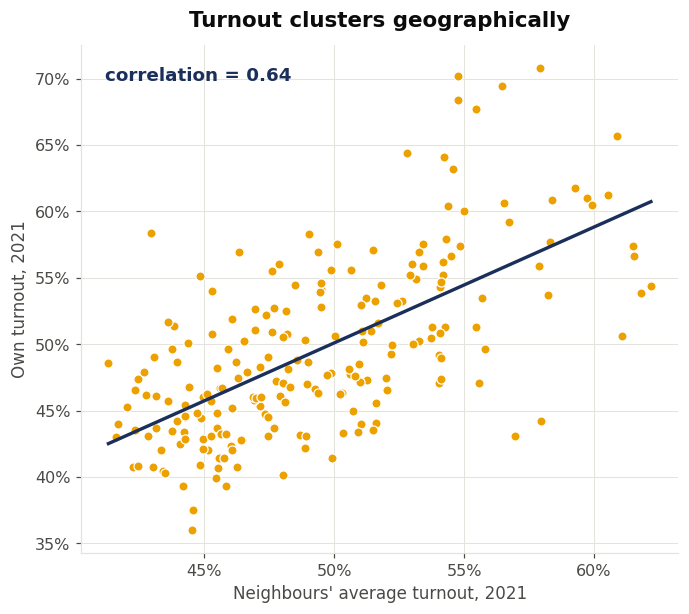

Same election: 0.64   |   neighbours' turnout at the previous election (2016): 0.54


In [ ]:
sp = y21.dropna(subset=["spatial_lag_turnout", "t"])
rho = sp["t"].corr(sp["spatial_lag_turnout"])
lag_2016 = master[master["election"] == 2016].set_index("muni_code")["spatial_lag_turnout"]
rho_prev = sp["t"].corr(sp["muni_code"].map(lag_2016))

fig, ax = plt.subplots(figsize=(7, 6))
ax.scatter(sp["spatial_lag_turnout"], sp["t"], s=36, color=AMBER, edgecolor=SURFACE, linewidth=0.8)
b, a = np.polyfit(sp["spatial_lag_turnout"], sp["t"], 1)
xs = np.linspace(sp["spatial_lag_turnout"].min(), sp["spatial_lag_turnout"].max(), 50)
ax.plot(xs, a + b * xs, color=NAVY, lw=2.2)
ax.annotate(f"correlation = {rho:.2f}", (0.04, 0.93), xycoords="axes fraction", fontsize=12, color=NAVY, weight="bold")
pct(ax); pct(ax, "x"); tidy(ax, xgrid=True)
ax.set(xlabel="Neighbours' average turnout, 2021", ylabel="Own turnout, 2021", title="Turnout clusters geographically")
save(fig, "q06_clustering"); plt.show()
print(f"Same election: {rho:.2f}   |   neighbours' turnout at the previous election (2016): {rho_prev:.2f}")

**Answer.** **Yes.** A municipality's turnout is strongly related to its neighbours' turnout in the same election
(correlation **0.64**), and still clearly related to their turnout at the previous election (**0.54**). Low turnout is
regional — for example across parts of Limpopo, North West and Mpumalanga.

**Careful.** Clustering suggests regional causes but does not identify them. The model uses neighbours' turnout at
the *previous* election, because when forecasting 2026 nobody's 2026 turnout is known.

**Was 2021 just COVID?** See `08_model` section 8b, which compares each municipality's 2024 national-election
turnout with its 2021 local turnout (after removing the usual 2016 → 2019 local-to-national gap). **In cities the
2021 drop was COVID; in rural municipalities turnout is really falling:** the densest municipalities returned to
their normal pattern in 2024, while the least dense are still about 10% below theirs.

## Q7. How does population density affect low turnout?

In [ ]:
import seaborn as sns
from scipy import stats
import matplotlib.ticker as mtick

d7 = y21.dropna(subset=["pop_density", "leak_turn"])
corr7, p7 = stats.pearsonr(np.log(d7["pop_density"]), d7["leak_turn"])

fig, ax = plt.subplots(figsize=(9, 5.5))
sns.regplot(data=d7, x="pop_density", y="leak_turn", logx=True, ax=ax, ci=95,
            scatter_kws={"alpha": 0.7, "color": AMBER, "edgecolors": SURFACE, "linewidths": 0.5, "s": 36},
            line_kws={"color": BLUE, "linewidth": 2.5})           # the 95% band takes the line's colour: light blue
ax.set_xscale("log")
ax.xaxis.set_major_locator(mtick.FixedLocator([1, 10, 100, 1000]))
ax.xaxis.set_major_formatter(mtick.FuncFormatter(lambda v, _: f"{v:,.0f}"))
ax.text(0.03, 0.93, f"correlation = {corr7:.2f}", transform=ax.transAxes, fontsize=13, weight="bold", color=NAVY)
ax.set(title="Denser municipalities have lower turnout", xlabel="People per km² (log scale)",
       ylabel="Turnout vs typical municipality, 2021")
pct(ax); tidy(ax)
save(fig, "q07_density"); plt.show()
print(f"Correlation with log density: {corr7:.3f} (p-value {p7:.4f})")

**Answer.** Denser municipalities had lower turnout than a typical municipality in 2021 (correlation **−0.50**): metros and large urban municipalities lost more voters between registration and the ballot box than smaller ones.

**Careful.** Density is a stand-in for many things at once (urban living, migration, COVID restrictions in 2021), so this is a link, not a cause. See `08_model` section 8b: in 2024 the densest municipalities returned to their normal pattern (their 2021 drop was
COVID), while rural municipalities are still below theirs.

---
# D. What to do

## Q8. Where should effort go before 4 November 2026?

2026 has no turnout yet, so we combine **what we know now** (the 2026 roll) with **what happened last time** (2021
turnout), and turn each shortfall into **people**: how many more registrations, and how many more voters, would bring
the municipality up to the typical level. *(The dashboard uses the model's predicted 2026 turnout instead.)*

In [ ]:
prio = y26[["muni_code", "muni_name", "province", "leak_reg", "r", "registered", "eligible_adults"]].merge(
    y21[["muni_code", "leak_turn", "t"]], on="muni_code")
prio["group"] = group_of(prio["leak_reg"], prio["leak_turn"])
prio["shortfall"] = -(prio["leak_reg"] + prio["leak_turn"])            # bigger = further below typical
r_typ, t_typ = prio["r"].median(), prio["t"].median()
prio["registrations_needed"] = (r_typ * prio["eligible_adults"] - prio["registered"]).clip(lower=0).round(-1)
prio["extra_voters_needed"] = ((t_typ - prio["t"]) * prio["registered"]).clip(lower=0).round(-1)
prio["what_to_send"] = prio["group"].map(WHAT_TO_SEND)

print(prio["group"].value_counts().reindex(GROUPS).to_string(), "\n")
top = prio.nlargest(15, "shortfall")
print(top[["muni_name", "province", "r", "t", "registrations_needed", "extra_voters_needed", "what_to_send"]]
      .assign(r=lambda d: (d["r"] * 100).round(1), t=lambda d: (d["t"] * 100).round(1))
      .rename(columns={"muni_name": "Municipality", "province": "Province", "r": "Registration 2026 %",
                       "t": "Turnout 2021 %", "registrations_needed": "Registrations needed",
                       "extra_voters_needed": "Extra voters needed", "what_to_send": "What to send"})
      .to_string(index=False))

group
Low registration    39
Low turnout         39
Both low            67
Healthy             68 

           Municipality      Province  Registration 2026 %  Turnout 2021 %  Registrations needed  Extra voters needed                            What to send
                Mkhondo    Mpumalanga                 48.8            43.1               49100.0               4060.0                   both - first priority
             Msukaligwa    Mpumalanga                 57.6            40.3               28300.0               6080.0                   both - first priority
        Thembisile Hani    Mpumalanga                 60.6            40.7               50610.0              12580.0                   both - first priority
               Emfuleni       Gauteng                 58.2            43.7              130790.0              16780.0                   both - first priority
               Mafikeng    North West                 67.8            37.6               24230.0              

**Answer.** The table lists the 15 municipalities furthest below a typical municipality on registration and turnout
together, with the number of **registrations** and **extra voters** that would bring each up to typical, and what to
send. **67 municipalities are below typical on both** — they are the first priority; most of the top 15 are in
Mpumalanga and Gauteng.

**Careful.** "Typical" is the median municipality, not a target set by the IEC. Registration rates above 100% in a
few small Northern Cape municipalities come from the Census sample, not from real over-registration.

Municipalities that suffer from both low registration and low turnout are given first priority because they face a dual-sided deficit, struggling simultaneously with low voter enrollment on the roll and poor voter turnout on election day.

Action required: They are flagged as top priority (first priority) for comprehensive interventions that tackle both challenges simultaneously (such as combining registration drives, ID/address assistance, and voter education/mobilisation).

In [ ]:
print("Figures written to", FIGURES)
for f in sorted(FIGURES.glob("q0*.png")):
    print(" ", f.name)

Figures written to /content/drive/MyDrive/DIRISA_SDC/reports/figures
  q01_registration_turnout.png
  q02_provinces.png
  q03_lowest_turnout.png
  q04_age_groups.png
  q05_correlations.png
  q06_clustering.png
  q07_density.png
